Dataset:
   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


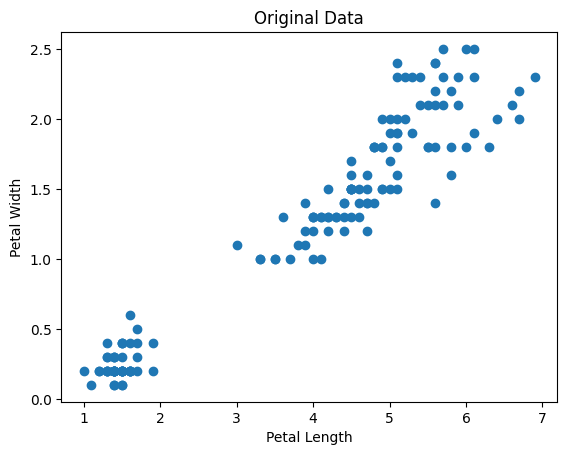


Scaled Data:
   petal length (cm)  petal width (cm)
0           0.067797          0.041667
1           0.067797          0.041667
2           0.050847          0.041667
3           0.084746          0.041667
4           0.067797          0.041667


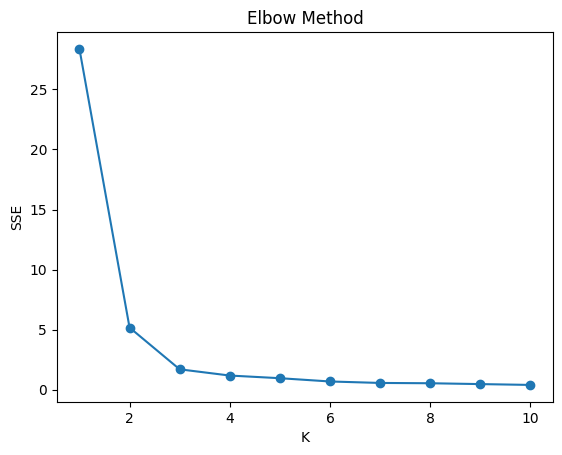


Clustered Data:
   petal length (cm)  petal width (cm)  cluster
0           0.067797          0.041667        1
1           0.067797          0.041667        1
2           0.050847          0.041667        1
3           0.084746          0.041667        1
4           0.067797          0.041667        1

Cluster Centers:
[[0.7740113  0.81510417]
 [0.07830508 0.06083333]
 [0.55867014 0.51041667]]


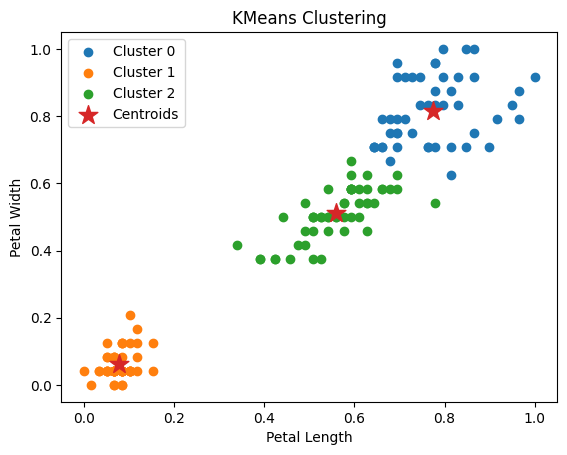

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

# Load iris dataset
iris = load_iris()

# Create dataframe using only
# petal length and petal width

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Keep only required features
df = df[['petal length (cm)', 'petal width (cm)']]

# Display dataset
print("Dataset:")
print(df.head())

# ---------------------------------------------------
# Visualize Original Data
# ---------------------------------------------------

plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)']
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Original Data')
plt.show()

# ---------------------------------------------------
# Feature Scaling
# ---------------------------------------------------

scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

# Convert back to dataframe
df_scaled = pd.DataFrame(
    df_scaled,
    columns=[
        'petal length (cm)',
        'petal width (cm)'
    ]
)

print("\nScaled Data:")
print(df_scaled.head())

# ---------------------------------------------------
# Elbow Method
# ---------------------------------------------------

sse = []

k_range = range(1, 11)

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(df_scaled)

    # SSE = Sum of Squared Errors
    sse.append(km.inertia_)

# Plot elbow graph
plt.plot(k_range, sse, marker='o')

plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()

# ---------------------------------------------------
# Train Final KMeans Model
# ---------------------------------------------------

# From elbow plot, optimal K usually = 3

km = KMeans(
    n_clusters=3,
    random_state=42
)

# Predict clusters
y_predicted = km.fit_predict(df_scaled)

# Add cluster column
df_scaled['cluster'] = y_predicted

print("\nClustered Data:")
print(df_scaled.head())

# ---------------------------------------------------
# Display Cluster Centers
# ---------------------------------------------------

print("\nCluster Centers:")
print(km.cluster_centers_)

# ---------------------------------------------------
# Visualize Clusters
# ---------------------------------------------------

df0 = df_scaled[df_scaled.cluster == 0]
df1 = df_scaled[df_scaled.cluster == 1]
df2 = df_scaled[df_scaled.cluster == 2]

plt.scatter(
    df0['petal length (cm)'],
    df0['petal width (cm)'],
    label='Cluster 0'
)

plt.scatter(
    df1['petal length (cm)'],
    df1['petal width (cm)'],
    label='Cluster 1'
)

plt.scatter(
    df2['petal length (cm)'],
    df2['petal width (cm)'],
    label='Cluster 2'
)

# Plot centroids
plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    marker='*',
    s=200,
    label='Centroids'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.legend()

plt.title('KMeans Clustering')
plt.show()